In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from py2cfg import CFGBuilder
from pydriller import Repository

In [2]:
df = pd.read_csv("./OpenHands_results/commits_info.csv")

In [3]:
old = df['old_file_mcc']
new = df['new_file_mcc']
print(f"Number of non-NAN values in old_file_mcc / Number of modifications: {len(df) - old.isna().sum()}/{len(df)}")
print(f"Number of non-NAN values in new_file_mcc / Number of modifications: {len(df) - new.isna().sum()}/{len(df)}")

Number of non-NAN values in old_file_mcc / Number of modifications: 1034/2481
Number of non-NAN values in new_file_mcc / Number of modifications: 1371/2481


In [4]:
new_df = df.dropna(subset=['old_file_mcc', 'new_file_mcc'])
print(f"Number of modifications with non-NAN values of both old_file_mcc and new_file_mcc: {len(new_df)}")

Number of modifications with non-NAN values of both old_file_mcc and new_file_mcc: 1017


In [5]:
print("Most frequently changed python files:")
new_df['new_file_path'].value_counts().head(10)

Most frequently changed python files:


new_file_path
openhands/runtime/impl/remote/remote_runtime.py    26
openhands/llm/llm.py                               25
openhands/server/session/manager.py                25
openhands/server/routes/manage_conversations.py    23
openhands/controller/agent_controller.py           23
openhands/server/session/agent_session.py          21
openhands/server/listen_socket.py                  20
openhands/server/routes/settings.py                19
openhands/runtime/base.py                          18
openhands/server/session/session.py                17
Name: count, dtype: int64

In [ ]:
cnt = 0
preferred_file = "openhands/server/routes/settings.py"
commit_hashes = new_df['commit_SHA'][new_df['new_file_path'] == preferred_file]
for x in Repository("OpenHands",only_no_merge=True,skip_whitespaces=True, histogram_diff = True).traverse_commits():
  if (x.in_main_branch==True):
    if x.hash in commit_hashes.values:
      for m in x.modified_files:
        if m.new_path == preferred_file:
          with open("./temp.py", "w") as f:
            f.write(m.source_code)
          f.close()
          cfg = CFGBuilder().build_from_file(f'Time: t = {cnt}', "./temp.py")
          cfg.build_visual(f'./media/{cnt}', 'pdf')
          cnt += 1
          print(cnt)
print("Number of CFGs saved: ", cnt)

In [7]:
old_file_mcc = new_df['old_file_mcc'][new_df['new_file_path'] == preferred_file]
new_file_mcc = new_df['new_file_mcc'][new_df['new_file_path'] == preferred_file]
len(old_file_mcc), len(new_file_mcc)

(19, 19)

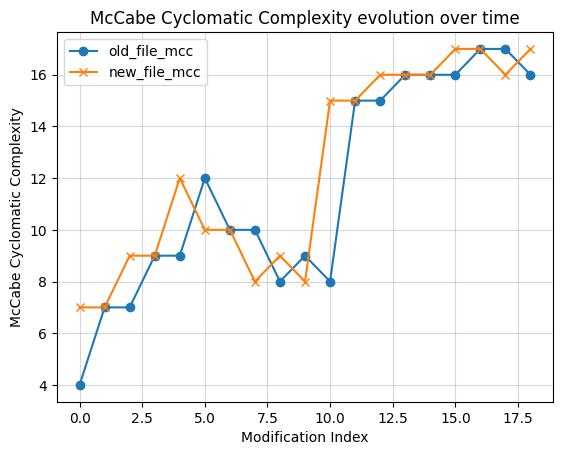

In [8]:
plt.plot(np.arange(len(old_file_mcc)), old_file_mcc, label='old_file_mcc', marker = 'o')
plt.plot(np.arange(len(new_file_mcc)), new_file_mcc, label='new_file_mcc', marker = 'x')
plt.legend()
plt.xlabel("Modification Index")
plt.ylabel("McCabe Cyclomatic Complexity")
plt.title("McCabe Cyclomatic Complexity evolution over time")
plt.grid(alpha=0.5)
plt.show()